# 1 · plot — Top7 contact map

Draws the dataset written by [`1_make_top7_heatmap_data.ipynb`](1_make_top7_heatmap_data.ipynb).
No GPU, no model: everything comes from the stored prediction.

Two figures, because the two are read differently — a single mirrored square when the reader
should see one object, and two panels when they should compare like with like:

* `top7_heatmap_mirrored` — prediction above the diagonal, observed contacts below.
* `top7_heatmap_side_by_side` — observed on the left, predicted on the right.

Both are masked to the pairs the metric scores: a blank region means *not scorable* (an
unresolved residue, or separation < 6), not *no contact*.

In [1]:
# Run from anywhere: figlib lives next to this notebook.
import sys
from pathlib import Path

HERE = Path.cwd() if (Path.cwd() / "figlib.py").exists() else Path("notebooks/figures")
sys.path.insert(0, str(HERE.resolve()))
import figlib

In [2]:
DATASET = "1_top7_heatmap"
DPI = 300                # PNG resolution; the PDF beside it is vector
metadata = figlib.describe(DATASET)

dataset      1_top7_heatmap
made by      1_make_top7_heatmap_data.ipynb
generated    2026-08-21T15:36:28+00:00
machine      ip1 · python 3.11.14 · NVIDIA RTX A5000 (23.7 GiB, cc 8.6)
checkout     fef976aa21de on exp250/evals-exploration-notebook  ** UNCOMMITTED CHANGES **
packages     marinfold 0.1.0, torch 2.5.1+cu121, transformers 4.57.6, numpy 2.4.6, pandas 3.0.5, matplotlib 3.11.1

parameters
   protein                  denovo_pdb__1qys_A
   model                    contacts-v1-exp232-m2-p06-1.5B
   n_rollouts               100
   temperature              1.0
   top_p                    0.95
   top_k                    -1
   backend                  auto
   dtype                    auto
   gpu_memory_utilization   0.85

model
   nickname                 contacts-v1-exp232-m2-p06-1.5B
   rope_theta               500000
   vocab_size               2845
   weights                  5.48 GiB

inputs
   17336c8bcfdc        114,366 B  /home/bizon/git/MarinFold/.claude/worktrees/evals-expl

In [3]:
import json

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

figlib.figure_style(DPI)
directory = figlib.dataset_dir(DATASET)
score = np.load(directory / "score.npy")
truth_record = json.loads((directory / "ground_truth.json").read_text())

length = truth_record["L"]
truth = figlib.true_matrix(length, truth_record["contacts"])
resolved = np.zeros(length, bool)
resolved[np.asarray(truth_record["resolved"])] = True
scorable = np.outer(resolved, resolved)
scorable &= np.abs(np.subtract.outer(np.arange(length), np.arange(length))) >= figlib.MIN_SEPARATION
upper = np.triu(np.ones((length, length), bool), k=1)
confidence = np.where(scorable, score, np.nan)
confidence = confidence / max(1.0, np.nanmax(confidence))

HEAT = LinearSegmentedColormap.from_list("votes", ["#FFFFFF", "#F4C36B", "#C44E52", "#3B0A0C"])
OBSERVED = LinearSegmentedColormap.from_list("gt", ["#2F2F2F", "#2F2F2F"])
print(f"{truth_record['stem']}  L={length}  {int(truth.sum() // 2)} observed contacts")

1qys_A  L=92  76 observed contacts


wrote /home/bizon/git/MarinFold/.claude/worktrees/evals-exploration-notebook-cba1c7/notebooks/figures/output/top7_heatmap_mirrored.png (300 dpi) and top7_heatmap_mirrored.pdf


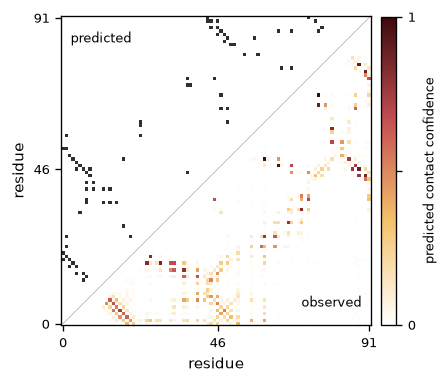

In [4]:
# --- mirrored square ---------------------------------------------------------------------------
figure, axis = plt.subplots(figsize=(3.6, 3.6))
image = axis.imshow(np.where(upper, confidence, np.nan), cmap=HEAT, origin="lower",
                    interpolation="none", vmin=0, vmax=1)
axis.imshow(np.where(~upper & truth & scorable, 1.0, np.nan), cmap=OBSERVED, origin="lower",
            interpolation="none", vmin=0, vmax=1)
axis.plot([0, length - 1], [0, length - 1], color="0.75", lw=0.6)
axis.set(xlabel="residue", ylabel="residue")
axis.set_xticks([0, length // 2, length - 1])
axis.set_yticks([0, length // 2, length - 1])
for spine in ("top", "right"):
    axis.spines[spine].set_visible(True)
bar = figure.colorbar(image, ax=axis, fraction=0.046, pad=0.03, ticks=[0, 0.5, 1.0])
bar.set_label("predicted contact confidence", fontsize=8)
bar.ax.set_yticklabels(["0", "", "1"])
axis.text(0.03, 0.95, "predicted", transform=axis.transAxes, ha="left", va="top", fontsize=8)
axis.text(0.97, 0.05, "observed", transform=axis.transAxes, ha="right", va="bottom", fontsize=8)
figlib.save_figure(figure, "top7_heatmap_mirrored", DPI)
plt.show()

wrote /home/bizon/git/MarinFold/.claude/worktrees/evals-exploration-notebook-cba1c7/notebooks/figures/output/top7_heatmap_side_by_side.png (300 dpi) and top7_heatmap_side_by_side.pdf


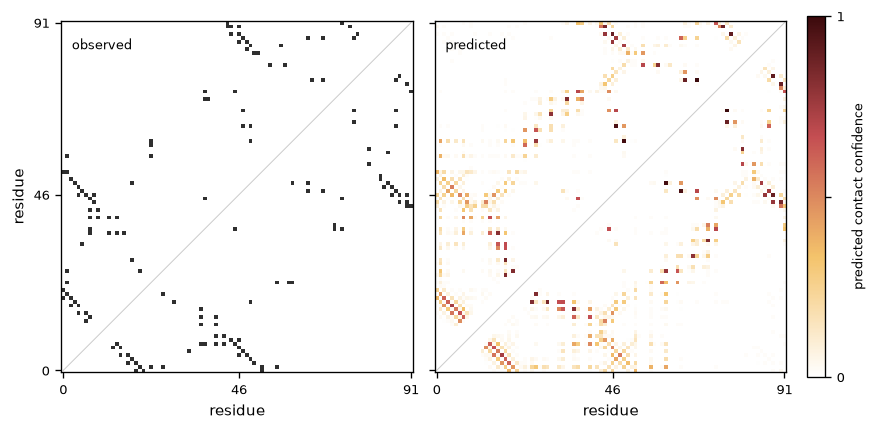

In [5]:
# --- side by side ------------------------------------------------------------------------------
# constrained_layout with the colorbar attached to BOTH axes keeps the panels the same size;
# hanging it off the right panel alone silently shrinks that one.
figure, axes = plt.subplots(1, 2, figsize=(7.2, 3.5), sharey=True, layout="constrained")
axes[0].imshow(np.where(truth & scorable, 1.0, np.nan), cmap=OBSERVED, origin="lower",
               interpolation="none", vmin=0, vmax=1)
image = axes[1].imshow(confidence, cmap=HEAT, origin="lower", interpolation="none", vmin=0, vmax=1)
axes[0].set(xlabel="residue", ylabel="residue")
axes[1].set(xlabel="residue")
for axis, note in zip(axes, ("observed", "predicted")):
    axis.plot([0, length - 1], [0, length - 1], color="0.8", lw=0.6)
    axis.set_xticks([0, length // 2, length - 1])
    axis.set_yticks([0, length // 2, length - 1])
    axis.text(0.03, 0.95, note, transform=axis.transAxes, ha="left", va="top", fontsize=8)
    for spine in ("top", "right"):
        axis.spines[spine].set_visible(True)
bar = figure.colorbar(image, ax=list(axes), fraction=0.046, pad=0.02, ticks=[0, 0.5, 1.0])
bar.set_label("predicted contact confidence", fontsize=8)
bar.ax.set_yticklabels(["0", "", "1"])
figlib.save_figure(figure, "top7_heatmap_side_by_side", DPI)
plt.show()

In [6]:
# The first few statements of the real document, for a format panel.
print("".join((figlib.dataset_dir(DATASET) / "document.txt").read_text()[:220]), "...")

<contacts-v1> <begin_sequence> <p28> <VAL> <p43> <ARG> <p48> <ILE> <p85> <THR> <p86> <VAL> <p49> <THR> <p22> <GLU> <p4> <VAL> <p57> <GLU> <p66> <VAL> <p78> <THR> <p59> <PHE> <p88> <GLY> <p14> <ASP> <p2> <VAL> <p80> <ASP> ...
